# Data Iris (Data Understanding)

Pada eksplorasi kali ini, kita akan menggunakan **Dataset Iris**. Dataset ini memang cukup populer dan sering dipakai untuk belajar dasar-dasar *Data Mining*, khususnya untuk kasus klasifikasi.

Nah, untuk pengumpulan datanya, kita tidak sekadar *download* file mentah dari internet. Sebagai bentuk praktik integrasi data, data ini ditarik terlebih dahulu dari database relasional (**PostgreSQL & MySQL**). Setelah itu, datanya diekspor menjadi file CSV (`IRIS.csv`) agar lebih mudah diolah di dalam Jupyter Notebook. 

Nantinya, hasil analisis dari *coding* kita ini juga akan kita bandingkan dengan visualisasi dari aplikasi **Orange Data Mining**.

---

## 1. Struktur dan Dimensi Data

Langkah paling awal di tahap *Data Understanding* tentu saja melihat langsung isi dan ukuran datanya. Dataset Iris ini mencatat ukuran fisik dari tiga jenis bunga Iris.

* **Dimensi:** Dataset ini memiliki **150 baris** data dan **5 kolom** (atribut).
* **Atribut Numerik (4 Fitur):** `sepal_length` (panjang kelopak), `sepal_width` (lebar kelopak), `petal_length` (panjang mahkota), dan `petal_width` (lebar mahkota).
* **Atribut Kategorikal (1 Target):** Kolom `species` yang berisi label jenis bunganya (*Iris-setosa*, *Iris-versicolor*, dan *Iris-virginica*). Masing-masing jenis bunga memiliki tepat 50 sampel, sehingga datanya sangat seimbang.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Memuat Dataset
df_iris = pd.read_csv('IRIS.csv')

# Menampilkan informasi dimensi dan tipe data
print(f"Dimensi Dataset: {df_iris.shape[0]} baris dan {df_iris.shape[1]} kolom\n")
print("Informasi Tipe Data:")
df_iris.info()

print("\nCuplikan 5 Data Teratas:")
display(df_iris.head())

Dimensi Dataset: 150 baris dan 5 kolom

Informasi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Cuplikan 5 Data Teratas:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 2. Validasi Kualitas Data (Missing Values & Outliers)

Sebelum datanya diolah lebih jauh, kita wajib ngecek apakah datanya sudah bersih. Ada dua hal utama yang harus dicek: data kosong (Missing Value) dan data aneh (Outlier).

### **A. Pengecekan Missing Value**
Kita pastikan dulu nggak ada sel data yang kosong. Kalau ada yang kosong, perhitungan jarak atau pemodelan ke depannya bisa *error*.

In [2]:
print("Laporan Missing Values:\n", df_iris.isnull().sum())
print("\nKesimpulan: Aman! Nggak ada data kosong di dataset ini.")

Laporan Missing Values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Kesimpulan: Aman! Nggak ada data kosong di dataset ini.


### **B. Deteksi Outliers**
*Outlier* adalah data yang nilainya melenceng jauh dari rata-rata temannya. Biar gampang nyarinya, kita langsung pakai visualisasi **Violin Plot** dan **Boxplot**.

Sebagai validasi, ini juga bisa kita cek lewat **Orange Data Mining** pakai widget *Box Plot*.
![Box Plot Outlier Orange](box_plot.png)


Ini versi visualisasi pakai Python-nya:

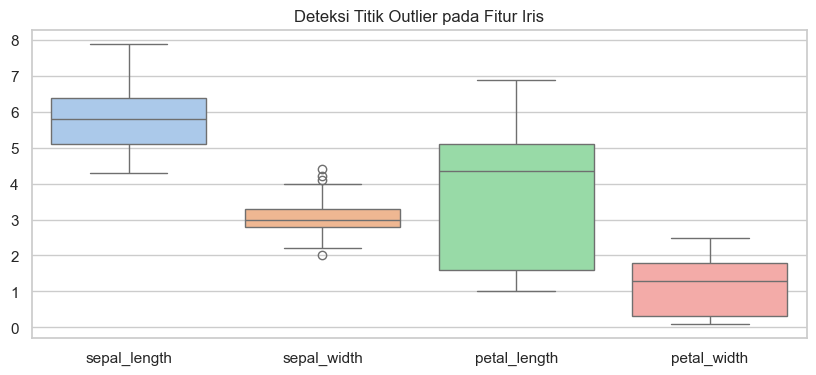

In [3]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 4))

# Bikin Boxplot buat ngecek titik pencilan
sns.boxplot(data=df_iris.drop('species', axis=1), palette="pastel")
plt.title("Deteksi Titik Outlier pada Fitur Iris")
plt.show()

**Hasil Pengecekan:**
Dari grafik di atas, kelihatan ada beberapa titik hitam di luar garis pada kolom `sepal_width`. Itu adalah data *outlier*. Tapi karena ini data ukuran bunga alami (bukan salah ketik), datanya tetap kita pakai dan nggak dibuang.

---

## 3. Gambaran Statistik Awal (Describe Data)

Biar kebayang karakteristik angkanya, kita hitung nilai statistik deskriptifnya. Ini mencakup **Ukuran Pemusatan** (Mean, Median, Modus) dan **Ukuran Sebaran Data** (Range, Quartil, Standar Deviasi, Variansi, dan Skewness).

Buat contoh implementasinya, kita hitung detail untuk satu fitur aja, yaitu **`sepal_length`**.

In [4]:
from scipy import stats

print("--- Statistik Deskriptif: Sepal Length ---")
print("Jumlah data     : ", df_iris['sepal_length'].count())
print("Rata-rata (Mean): ", df_iris['sepal_length'].mean())
print("Nilai Minimal   : ", df_iris['sepal_length'].min())
print("Q1 (25%)        : ", df_iris['sepal_length'].quantile(0.25))
print("Q2 (Median/50%) : ", df_iris['sepal_length'].quantile(0.5))
print("Q3 (75%)        : ", df_iris['sepal_length'].quantile(0.75))
print("Nilai Max       : ", df_iris['sepal_length'].max())

# Menghitung Modus menggunakan scipy
mode_val = stats.mode(df_iris['sepal_length'], keepdims=True)
print("Nilai Modus     : {} (muncul sebanyak {} kali)".format(mode_val.mode[0], mode_val.count[0]))

print("Kemencengan (Skewness) : ", "{0:.2f}".format(round(df_iris['sepal_length'].skew(), 2)))
print("Standar Deviasi : ", "{0:.2f}".format(round(df_iris['sepal_length'].std(), 2)))
print("Variansi        : ", "{0:.2f}".format(round(df_iris['sepal_length'].var(), 2)))

--- Statistik Deskriptif: Sepal Length ---
Jumlah data     :  150
Rata-rata (Mean):  5.843333333333334
Nilai Minimal   :  4.3
Q1 (25%)        :  5.1
Q2 (Median/50%) :  5.8
Q3 (75%)        :  6.4
Nilai Max       :  7.9
Nilai Modus     : 5.0 (muncul sebanyak 10 kali)
Kemencengan (Skewness) :  0.31
Standar Deviasi :  0.83
Variansi        :  0.69


### **Penjelasan Singkat Hasil Statistik**

| Jenis Statistika | Nilai | Keterangan |
| :--- | :--- | :--- |
| **Jumlah Data (n)** | 150 | Total baris data yang diproses. |
| **Rata-rata (Mean)** | 5.84 | Nilai rata-rata panjang kelopak bunga. |
| **Median (Q2)** | 5.80 | Nilai tengah datanya setelah diurutkan. |
| **Modus (Mode)** | 5.0 | Ukuran panjang kelopak yang paling banyak ditemui (ada 10 bunga). |
| **Nilai Min - Max** | 4.30 - 7.90 | Rentang ukuran panjang kelopak terkecil sampai terbesar. |
| **Kuartil 1 & 3** | 5.10 & 6.40 | Menandakan batas 25% data terbawah dan 75% data terbawah. |
| **Standar Deviasi** | 0.83 | Makin besar nilainya, makin bervariasi ukuran kelopaknya. |
| **Variansi** | 0.69 | Nilai kuadrat dari standar deviasi. |

Visualisasi distribusi dan perhitungan seperti ini juga bisa kita dapatkan dengan gampang menggunakan widget **Distributions** di **Orange**.

![Histogram Orange](histogram.png)

---

## 4. Statistik Tiap Spesies & Visualisasi Sebaran

Nah, kalau tadi cuma ngecek data secara umum, sekarang kita kelompokin berdasarkan jenis bunganya. Ini penting banget buat algoritma klasifikasi, biar ketahuan fitur mana yang paling beda antar spesiesnya.

In [5]:
# Nampilin rata-rata dan detail lainnya, tapi dikelompokin per jenis bunga
print("Statistik Berdasarkan Spesies:")
display(df_iris.groupby('species').describe().T)

Statistik Berdasarkan Spesies:


species             Iris-setosa  Iris-versicolor  Iris-virginica
sepal_length count    50.000000        50.000000       50.000000
             mean      5.006000         5.936000        6.588000
             std       0.352490         0.516171        0.635880
             min       4.300000         4.900000        4.900000
             25%       4.800000         5.600000        6.225000
             50%       5.000000         5.900000        6.500000
             75%       5.200000         6.300000        6.900000
             max       5.800000         7.000000        7.900000
sepal_width  count    50.000000        50.000000       50.000000
             mean      3.418000         2.770000        2.974000
             std       0.381024         0.313798        0.322497
             min       2.300000         2.000000        2.200000
             25%       3.125000         2.525000        2.800000
             50%       3.400000         2.800000        3.000000
             75%       3.675000         3.000000        3.175000
             max       4.400000         3.400000        3.800000
petal_length count    50.000000        50.000000       50.000000
             mean      1.464000         4.260000        5.552000
             std       0.173511         0.469911        0.551895
             min       1.000000         3.000000        4.500000
             25%       1.400000         4.000000        5.100000
             50%       1.500000         4.350000        5.550000
             75%       1.575000         4.600000        5.875000
             max       1.900000         5.100000        6.900000
petal_width  count    50.000000        50.000000       50.000000
             mean      0.244000         1.326000        2.026000
             std       0.107210         0.197753        0.274650
             min       0.100000         1.000000        1.400000
             25%       0.200000         1.200000        1.800000
             50%       0.200000         1.300000        2.000000
             75%       0.300000         1.500000        2.300000
             max       0.600000         1.800000        2.500000

Dari tabel di atas, kelihatan jelas kalau **Setosa** ukurannya mungil-mungil, beda jauh sama **Virginica** yang kelopak dan mahkotanya lebih besar.

Terakhir, biar makin yakin, kita bikin **Scatter Plot** buat ngecek hubungan antar fitur (misal panjang mahkota vs lebar mahkota). Ini juga bisa dicek di widget Orange!

![Scatter Plot Orange](scatterplot.png)